In [1]:
# Databricks notebook source
from pyspark import SparkConf, SparkContext

conf = SparkConf().setAppName("Read File")

sc = SparkContext.getOrCreate(conf=conf)

rdd = sc.textFile(r"StudentData.csv")


In [2]:
45*12


540

In [2]:
header = rdd.first()
rdd = rdd.filter(lambda line: line != header).map(lambda line: line.split(","))
rdd.take(5)

[['28',
  'Female',
  'Hubert Oliveras',
  'DB',
  '02984',
  '59',
  'Annika Hoffman_Naoma Fritts@OOP.com'],
 ['29',
  'Female',
  'Toshiko Hillyard',
  'Cloud',
  '12899',
  '62',
  'Margene Moores_Marylee Capasso@DB.com'],
 ['28',
  'Male',
  'Celeste Lollis',
  'PF',
  '21267',
  '45',
  'Jeannetta Golden_Jenna Montague@DSA.com'],
 ['29',
  'Female',
  'Elenore Choy',
  'DB',
  '32877',
  '29',
  'Billi Clore_Mitzi Seldon@DB.com'],
 ['28',
  'Male',
  'Sheryll Towler',
  'DSA',
  '41487',
  '41',
  'Claude Panos_Judie Chipps@OOP.com']]

# students average mark

In [33]:
averageMarks = round(rdd.map(lambda x:int(x[5])).mean(),2)
averageMarks

60.1

# Each course's average score

In [34]:
eachCourseAvg = rdd.map(lambda x: (x[3], (int(x[5]), 1))).\
    reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])).\
        map(lambda x: (x[0], round(x[1][0] / x[1][1], 2))).\
            sortBy(lambda x: x[1], ascending=False)
eachCourseAvg.take(10)

[('DSA', 62.22),
 ('MVC', 61.05),
 ('PF', 59.84),
 ('Cloud', 59.6),
 ('DB', 59.04),
 ('OOP', 58.66)]

# each students average score

In [41]:
eachStudentsTotal = rdd.map(lambda x: (x[2], (int(x[5]), 1))).\
    reduceByKey(lambda a,b: (a[0] + b[0], a[1] + b[1])).\
    map(lambda x: (x[0], x[1][0]/x[1][1])).\
    sortBy(lambda x: x[1], ascending=False)
eachStudentsTotal.take(10)

[('Jc Andrepont', 70.06666666666666),
 ('Cordie Harnois', 69.85714285714286),
 ('Priscila Tavernier', 67.16666666666667),
 ('Loris Crossett', 67.1304347826087),
 ('Melani Engberg', 67.05263157894737),
 ('Eda Neathery', 66.95238095238095),
 ('Celeste Lollis', 66.16666666666667),
 ('Judie Chipps', 65.91666666666667),
 ('Alberta Freund', 65.81818181818181),
 ('Jalisa Swenson', 64.5)]

# average score by sex


In [38]:
avaerage_by_sex = rdd.map(lambda x: (x[1], (int(x[5]), 1))).\
    reduceByKey(lambda a,b: (a[0] + b[0], a[1] + b[1])).\
    map(lambda x: (x[0], round(x[1][0]/x[1][1],2)))
avaerage_by_sex.take(5)

[('Female', 59.15), ('Male', 61.04)]

# age average score

In [4]:
age_score = rdd.map(lambda x:(int(x[0]),(int(x[5]),1))).\
    reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1])).\
    map(lambda x:(x[0],round(x[1][0]/x[1][1],2)))
age_score.take(5)

[(28, 60.49), (29, 59.72)]

# highest score for each course

In [5]:
highest_score_course = rdd.map(lambda x:(x[3],int(x[5]))).\
    reduceByKey(lambda a,b:max(a,b))
highest_score_course.take(5)

[('DB', 98), ('Cloud', 99), ('PF', 99), ('MVC', 99), ('OOP', 99)]

# score distribution

In [8]:
score_dist = rdd.map(lambda x: (int(x[5]), 1)) \
                .reduceByKey(lambda a, b: a+b).\
                sortBy(lambda x: x[0])
result = score_dist.collect()
print(result)


[(20, 9), (21, 10), (22, 9), (23, 15), (24, 15), (25, 8), (26, 13), (27, 17), (28, 12), (29, 10), (30, 13), (31, 10), (32, 16), (33, 10), (34, 15), (35, 9), (36, 18), (37, 13), (38, 9), (39, 10), (40, 11), (41, 12), (42, 17), (43, 10), (44, 8), (45, 13), (46, 18), (47, 12), (48, 8), (49, 6), (50, 14), (51, 14), (52, 12), (53, 13), (54, 14), (55, 10), (56, 10), (57, 15), (58, 10), (59, 15), (60, 18), (61, 7), (62, 15), (63, 11), (64, 14), (65, 10), (66, 13), (67, 12), (68, 14), (69, 14), (70, 11), (71, 15), (72, 18), (73, 9), (74, 7), (75, 11), (76, 18), (77, 22), (78, 16), (79, 15), (80, 10), (81, 20), (82, 11), (83, 11), (84, 16), (85, 11), (86, 12), (87, 8), (88, 17), (89, 13), (90, 6), (91, 12), (92, 12), (93, 9), (94, 19), (95, 10), (96, 13), (97, 15), (98, 10), (99, 12)]


# visualize score distribution

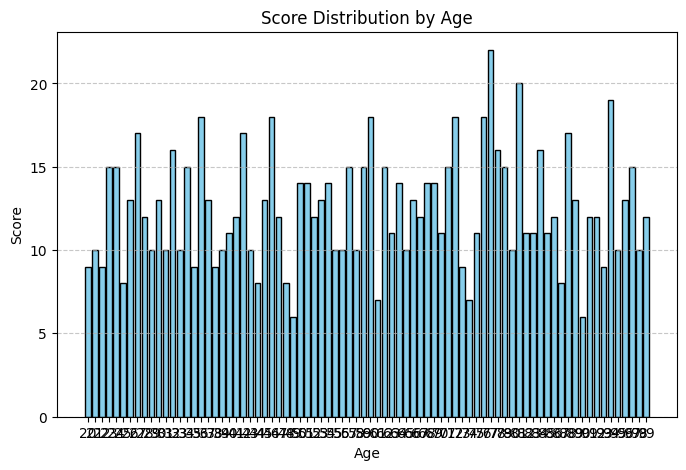

In [10]:
import matplotlib.pyplot as plt
scores = [item[0] for item in result]
counts = [item[1] for item in result]

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(scores, counts, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Score')
plt.title('Score Distribution by Age')
plt.xticks(scores)  # show all ages on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()

In [15]:
total = rdd.count()

score_dist_percent = rdd.map(lambda x: (int(x[5]), 1)) \
                .reduceByKey(lambda a, b: a+b)\
                .map(lambda x: (x[0], round((x[1]/total)*100,2)))\
                .sortBy(lambda x: x[0])
score_dist_percent.collect()

[(20, 0.9),
 (21, 1.0),
 (22, 0.9),
 (23, 1.5),
 (24, 1.5),
 (25, 0.8),
 (26, 1.3),
 (27, 1.7),
 (28, 1.2),
 (29, 1.0),
 (30, 1.3),
 (31, 1.0),
 (32, 1.6),
 (33, 1.0),
 (34, 1.5),
 (35, 0.9),
 (36, 1.8),
 (37, 1.3),
 (38, 0.9),
 (39, 1.0),
 (40, 1.1),
 (41, 1.2),
 (42, 1.7),
 (43, 1.0),
 (44, 0.8),
 (45, 1.3),
 (46, 1.8),
 (47, 1.2),
 (48, 0.8),
 (49, 0.6),
 (50, 1.4),
 (51, 1.4),
 (52, 1.2),
 (53, 1.3),
 (54, 1.4),
 (55, 1.0),
 (56, 1.0),
 (57, 1.5),
 (58, 1.0),
 (59, 1.5),
 (60, 1.8),
 (61, 0.7),
 (62, 1.5),
 (63, 1.1),
 (64, 1.4),
 (65, 1.0),
 (66, 1.3),
 (67, 1.2),
 (68, 1.4),
 (69, 1.4),
 (70, 1.1),
 (71, 1.5),
 (72, 1.8),
 (73, 0.9),
 (74, 0.7),
 (75, 1.1),
 (76, 1.8),
 (77, 2.2),
 (78, 1.6),
 (79, 1.5),
 (80, 1.0),
 (81, 2.0),
 (82, 1.1),
 (83, 1.1),
 (84, 1.6),
 (85, 1.1),
 (86, 1.2),
 (87, 0.8),
 (88, 1.7),
 (89, 1.3),
 (90, 0.6),
 (91, 1.2),
 (92, 1.2),
 (93, 0.9),
 (94, 1.9),
 (95, 1.0),
 (96, 1.3),
 (97, 1.5),
 (98, 1.0),
 (99, 1.2)]